In [1]:
# Core libraries
import os
import random
import json
import time

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

[HAMI-core Msg(3139:139836311424320:libvgpu.c:839)]: Initializing.....


In [29]:
# ============================================================
# Experiment configuration
# ============================================================

MODEL_NAME = "jhu-clsp/mmbert-base"

NUM_LABELS = 5
MAX_LENGTH = 128
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
NUM_EPOCHS = 8
SEED = 42
EARLY_STOPPING_PATIENCE = 2

# Dataset paths relative to the classifier notebook folder.
TRAIN_PATH = "../RUHSOLD_train.tsv"
VAL_PATH = "../RUHSOLD_validation.tsv"
TEST_PATH = "../RUHSOLD_test.tsv"

# Keep mmBERT checkpoints and analysis outputs separate.
OUTPUT_DIR = "./outputs/mmbert_baseline"
RESULTS_DIR = "./outputs/mmbert_results"

In [3]:
# ============================================================
# Load prepared RUHSOLD splits
# ============================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    sep="\t",
    names=["tweet", "label"]
)

val_df = pd.read_csv(
    VAL_PATH,
    sep="\t",
    names=["tweet", "label"]
)

test_df = pd.read_csv(
    TEST_PATH,
    sep="\t",
    names=["tweet", "label"]
)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Testing samples    : {len(test_df)}")

Training samples   : 6408
Validation samples : 801
Testing samples    : 2003


In [4]:
# Confirm the prepared files contain the expected five labels.
expected_labels = {0, 1, 2, 3, 4}

assert set(train_df["label"].unique()) == expected_labels
assert set(val_df["label"].unique()) == expected_labels
assert set(test_df["label"].unique()) == expected_labels

assert train_df["tweet"].notna().all()
assert val_df["tweet"].notna().all()
assert test_df["tweet"].notna().all()

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
# ============================================================
# Reproducibility setup
# ============================================================

import os
import random
import numpy as np
import torch

def set_seed(seed: int) -> None:
    """
    Set random seeds across Python, NumPy, and PyTorch.

    This reduces variation between repeated runs. Exact reproducibility
    can still depend on the GPU, CUDA version, and installed libraries.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Encourage deterministic CUDA behaviour where possible.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Device: cuda
GPU: NVIDIA A100 80GB PCIe
GPU memory: 16.0 GB


[HAMI-core Msg(3139:139836311424320:libvgpu.c:855)]: Initialized


In [6]:
# ============================================================
# RUHSOLD label mappings
# ============================================================

id2label = {
    0: "Abusive/Offensive",
    1: "Normal",
    2: "Religious Hate",
    3: "Sexism",
    4: "Profane"
}

label2id = {label: idx for idx, label in id2label.items()}

print("Label mapping:")
for label_id, label_name in id2label.items():
    print(f"{label_id}: {label_name}")

Label mapping:
0: Abusive/Offensive
1: Normal
2: Religious Hate
3: Sexism
4: Profane


In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", tokenizer.__class__.__name__)
print("Vocabulary size:", tokenizer.vocab_size)
print("Model maximum length:", tokenizer.model_max_length)

Tokenizer: TokenizersBackend
Vocabulary size: 256000
Model maximum length: 8192


In [8]:
# ============================================================
# PyTorch dataset class for RUHSOLD
# ============================================================

from torch.utils.data import Dataset

class RUHSOLDDataset(Dataset):
    """
    PyTorch Dataset for the RUHSOLD classification task.

    Each item contains:
    - input_ids
    - attention_mask
    - label
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        tokenizer,
        max_length: int
    ) -> None:
        """
        Store tweets, labels, tokenizer, and maximum sequence length.
        """
        self.tweets = dataframe["tweet"].astype(str).tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        """
        Return the number of samples in the dataset.
        """
        return len(self.tweets)

    def __getitem__(self, index: int) -> dict:
        """
        Tokenize one tweet and return it with its label.
        """
        tweet = self.tweets[index]
        label = self.labels[index]

        encoded = self.tokenizer(
            tweet,
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

        encoded["labels"] = label

        return encoded

In [9]:
# ============================================================
# Create train, validation, and test datasets
# ============================================================

train_dataset = RUHSOLDDataset(
    dataframe=train_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = RUHSOLDDataset(
    dataframe=val_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

test_dataset = RUHSOLDDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

print(f"Training dataset   : {len(train_dataset)}")
print(f"Validation dataset : {len(val_dataset)}")
print(f"Testing dataset    : {len(test_dataset)}")

Training dataset   : 6408
Validation dataset : 801
Testing dataset    : 2003


In [10]:
# ============================================================
# Inspect mBERT tokenization on sample tweets
# ============================================================

sample_tweets = [
    train_df.iloc[0]["tweet"],
    "tum bohat ache insan ho",
    "yeh bohat buri aur ghatiya baat hai"
]

for tweet in sample_tweets:
    tokens = tokenizer.tokenize(str(tweet))

    print("-" * 80)
    print("Tweet :", tweet)
    print("Tokens:", tokens)
    print("Number of tokens:", len(tokens))

--------------------------------------------------------------------------------
Tweet : kia howa hai aap ko allah bless and protect you  aameen
Tokens: ['▁kia', '▁how', 'a', '▁hai', '▁a', 'ap', '▁ko', '▁allah', '▁bless', '▁and', '▁protect', '▁you', '▁', '▁a', 'ame', 'en']
Number of tokens: 16
--------------------------------------------------------------------------------
Tweet : tum bohat ache insan ho
Tokens: ['▁tum', '▁bohat', '▁ache', '▁insan', '▁ho']
Number of tokens: 5
--------------------------------------------------------------------------------
Tweet : yeh bohat buri aur ghatiya baat hai
Tokens: ['▁yeh', '▁bohat', '▁bu', 'ri', '▁aur', '▁g', 'hati', 'ya', '▁ba', 'at', '▁hai']
Number of tokens: 11


In [11]:
# ============================================================
# Dynamic batch padding
# ============================================================

from transformers import DataCollatorWithPadding

# Pad each batch only to the longest sequence within that batch.
# This is more memory-efficient than padding every tweet to MAX_LENGTH.
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

In [12]:
# ============================================================
# Evaluation metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_prediction):
    """
    Compute evaluation metrics from model logits and true labels.

    Macro averaging gives equal importance to all five classes,
    which is necessary because RUHSOLD is class-imbalanced.
    """
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

In [13]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

print("Model:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmbert-base
Key               | Status     | 
------------------+------------+-
decoder.weight    | UNEXPECTED | 
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: ModernBertForSequenceClassification
Number of labels: 5


In [14]:
print("Checkpoint:", MODEL_NAME)
print("Loaded model class:", model.__class__.__name__)
print("Model type:", model.config.model_type)
print("Number of labels:", model.config.num_labels)

Checkpoint: jhu-clsp/mmbert-base
Loaded model class: ModernBertForSequenceClassification
Model type: modernbert
Number of labels: 5


In [15]:
import accelerate
import transformers

print("Accelerate version :", accelerate.__version__)
print("Transformers version:", transformers.__version__)

Accelerate version : 1.14.0
Transformers version: 5.8.0


In [16]:
%pip install -U "accelerate>=1.1.0"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [17]:
# ============================================================
# Check available storage before training
# ============================================================

import os
import shutil

disk = shutil.disk_usage(os.getcwd())

print(f"Used disk space : {disk.used / 1024**3:.2f} GB")
print(f"Free disk space : {disk.free / 1024**3:.2f} GB")

if disk.free / 1024**3 < 3:
    raise RuntimeError(
        "Less than 3 GB of storage is available. "
        "Free additional space before training."
    )

Used disk space : 18.80 GB
Free disk space : 5.70 GB


In [18]:
# ============================================================
# Training configuration
# ============================================================

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    eval_strategy="epoch",
    logging_strategy="epoch",

    # Save only when validation Macro F1 improves.
    save_strategy="best",
    save_total_limit=1,
    save_only_model=True,

    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    warmup_steps=240,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    seed=SEED,
    data_seed=SEED,

    bf16=torch.cuda.is_available(),
    fp16=False,

    report_to="none",
    disable_tqdm=False
)

print("mmBERT training arguments created successfully.")

[HAMI-core Msg(3408:139734147049280:multiprocess_memory_limit.c:455)]: Calling exit handler 3408


mmBERT training arguments created successfully.


In [19]:

# ============================================================
# Create Trainer with EarlyStoppingCallback
# ============================================================

from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,

    # Stop when validation Macro F1 has not improved for
    # two consecutive epoch-level evaluations.
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=0.0
        )
    ]
)

print("Trainer with early stopping created successfully.")

Trainer with early stopping created successfully.


In [20]:
# ============================================================
# Train mBERT with a maximum of 10 epochs and early stopping
# ============================================================

import time

start_time = time.time()

train_result = trainer.train()

training_time_seconds = time.time() - start_time

print("\nTraining completed.")
print(f"Total training time: {training_time_seconds / 60:.2f} minutes")
print(f"Epoch reached: {trainer.state.epoch:.0f}")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print(f"Best validation Macro F1: {trainer.state.best_metric:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.902555,0.654128,0.781523,0.741672,0.637370,0.673346,0.778228,0.781523,0.773657
2,0.452195,0.658747,0.786517,0.749693,0.666517,0.693195,0.790049,0.786517,0.781887
3,0.217196,1.552372,0.764045,0.684059,0.682472,0.680162,0.771724,0.764045,0.766460
4,0.053177,1.954728,0.789014,0.699719,0.714733,0.704046,0.788116,0.789014,0.786583
5,0.011104,1.948006,0.780275,0.696138,0.709610,0.702087,0.785689,0.780275,0.782480
6,0.002561,2.032895,0.789014,0.705036,0.703463,0.703936,0.786371,0.789014,0.787417


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed.
Total training time: 6.73 minutes
Epoch reached: 6
Best checkpoint: ./outputs/mmbert_baseline/checkpoint-3204
Best validation Macro F1: 0.7040


In [21]:
# ============================================================
# Extract epoch-level validation history
# ============================================================

import pandas as pd

history_df = pd.DataFrame(trainer.state.log_history)

validation_columns = [
    "epoch",
    "eval_loss",
    "eval_accuracy",
    "eval_macro_precision",
    "eval_macro_recall",
    "eval_macro_f1",
    "eval_weighted_precision",
    "eval_weighted_recall",
    "eval_weighted_f1"
]

validation_history = history_df.loc[
    history_df["eval_macro_f1"].notna(),
    validation_columns
].copy()

# Remove any repeated final-evaluation records.
validation_history = (
    validation_history
    .drop_duplicates(subset=["epoch"], keep="first")
    .sort_values("epoch")
    .reset_index(drop=True)
)

validation_history

,epoch,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_weighted_precision,eval_weighted_recall,eval_weighted_f1
0,1.0,0.654128,0.781523,0.741672,0.637370,0.673346,0.778228,0.781523,0.773657
1,2.0,0.658747,0.786517,0.749693,0.666517,0.693195,0.790049,0.786517,0.781887
2,3.0,1.552372,0.764045,0.684059,0.682472,0.680162,0.771724,0.764045,0.766460
3,4.0,1.954728,0.789014,0.699719,0.714733,0.704046,0.788116,0.789014,0.786583
4,5.0,1.948006,0.780275,0.696138,0.709610,0.702087,0.785689,0.780275,0.782480
5,6.0,2.032895,0.789014,0.705036,0.703463,0.703936,0.786371,0.789014,0.787417


In [22]:
# ============================================================
# Find the epoch with the highest validation Macro F1
# ============================================================

best_epoch = int(
    validation_history.loc[
        validation_history["eval_macro_f1"].idxmax(),
        "epoch"
    ]
)

print("Best epoch:", best_epoch)

Best epoch: 4


In [23]:
# ============================================================
# Save validation history and run summary
# ============================================================

import os
import json

os.makedirs(RESULTS_DIR, exist_ok=True)

validation_history.to_csv(
    os.path.join(RESULTS_DIR, "validation_history.csv"),
    index=False
)

best_run_summary = {
    "model_name": MODEL_NAME,
    "maximum_epochs": NUM_EPOCHS,
    "epochs_completed": float(trainer.state.epoch),
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "best_epoch": best_epoch,
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_validation_macro_f1": float(trainer.state.best_metric),
    "training_time_minutes": float(training_time_seconds / 60)
}

with open(
    os.path.join(RESULTS_DIR, "best_run_summary.json"),
    "w",
    encoding="utf-8"
) as file:
    json.dump(best_run_summary, file, indent=4)

print("mmBERT validation history and run summary saved.")

mmBERT validation history and run summary saved.


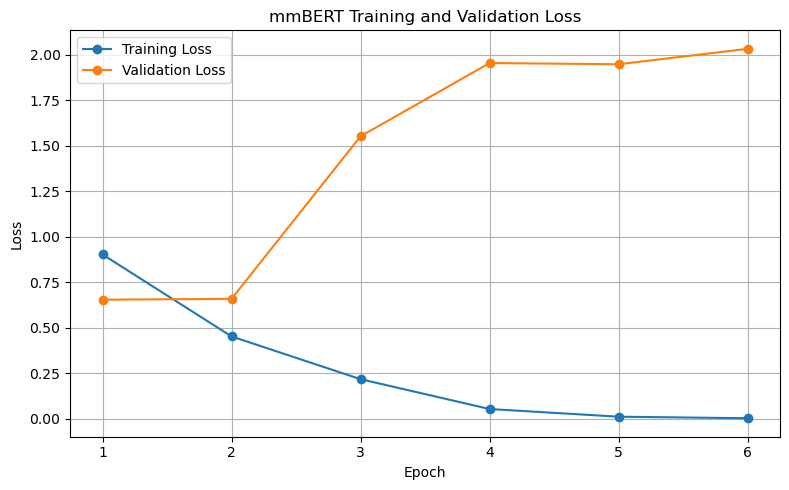

In [24]:
# ============================================================
# Plot and save mmBERT training and validation loss
# ============================================================

import matplotlib.pyplot as plt

history_df = pd.DataFrame(trainer.state.log_history)

train_loss_df = history_df.loc[
    history_df["loss"].notna(),
    ["epoch", "loss"]
].copy()

val_loss_df = history_df.loc[
    history_df["eval_loss"].notna(),
    ["epoch", "eval_loss"]
].copy()

train_loss_df = (
    train_loss_df
    .drop_duplicates(subset=["epoch"], keep="first")
    .sort_values("epoch")
)

val_loss_df = (
    val_loss_df
    .drop_duplicates(subset=["epoch"], keep="first")
    .sort_values("epoch")
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    train_loss_df["epoch"],
    train_loss_df["loss"],
    marker="o",
    label="Training Loss"
)

ax.plot(
    val_loss_df["epoch"],
    val_loss_df["eval_loss"],
    marker="o",
    label="Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("mmBERT Training and Validation Loss")
ax.legend()
ax.grid(True)

fig.tight_layout()

os.makedirs(RESULTS_DIR, exist_ok=True)

fig.savefig(
    os.path.join(RESULTS_DIR, "training_validation_loss.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ============================================================
# Generate predictions on the validation set
# ============================================================

import numpy as np

# Predict on the validation set using the best checkpoint.
validation_predictions = trainer.predict(val_dataset)

# True labels
y_true = validation_predictions.label_ids

# Predicted labels
y_pred = np.argmax(validation_predictions.predictions, axis=1)

print("Validation samples:", len(y_true))

Validation samples: 801


In [26]:
# ============================================================
# Per-class classification report
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

target_names = [
    "Abusive/Offensive",
    "Normal",
    "Religious Hate",
    "Sexism",
    "Profane"
]

report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Abusive/Offensive,0.725610,0.619792,0.668539,192.000000
Normal,0.881549,0.904206,0.892734,428.000000
Religious Hate,0.616438,0.714286,0.661765,63.000000
Sexism,0.675000,0.805970,0.734694,67.000000
Profane,0.600000,0.529412,0.562500,51.000000
accuracy,0.789014,0.789014,0.789014,0.789014
macro avg,0.699719,0.714733,0.704046,801.000000
weighted avg,0.788116,0.789014,0.786583,801.000000


In [27]:
# ============================================================
# Validation Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[119  32  12  13  16]
 [ 18 387  12  10   1]
 [  5  10  45   2   1]
 [  4   6   3  54   0]
 [ 18   4   1   1  27]]


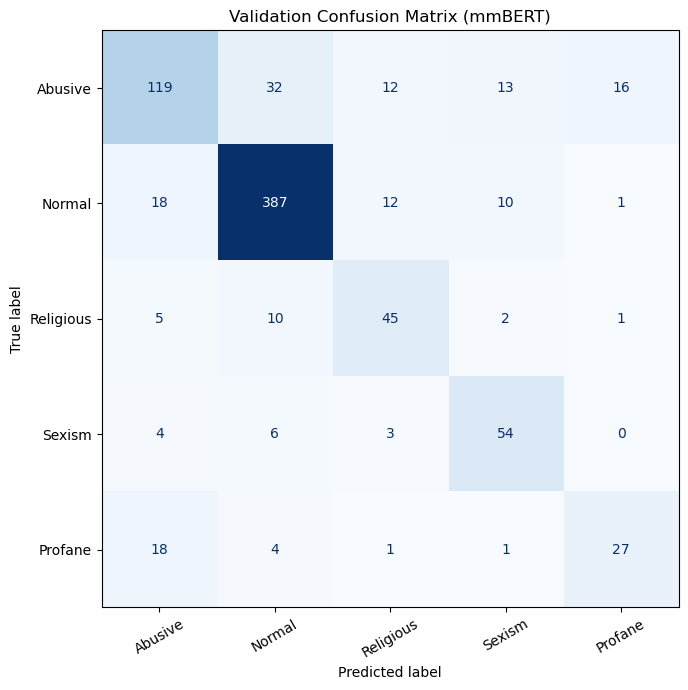

mmBERT report and confusion matrix saved successfully.


In [28]:
# ============================================================
# Plot and save mmBERT validation confusion matrix
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay
labels = [
    "Abusive",
    "Normal",
    "Religious",
    "Sexism",
    "Profane"
]

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title("Validation Confusion Matrix (mmBERT)")
plt.xticks(rotation=30)
fig.tight_layout()

os.makedirs(RESULTS_DIR, exist_ok=True)

fig.savefig(
    os.path.join(RESULTS_DIR, "validation_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

cm_df.to_csv(
    os.path.join(RESULTS_DIR, "validation_confusion_matrix.csv")
)

report_df.to_csv(
    os.path.join(RESULTS_DIR, "validation_classification_report.csv")
)

print("mmBERT report and confusion matrix saved successfully.")